# Portfolio Construction — ViT Candlestick Signals

**Group 5 | AI in Finance**  
**Reference:** *Learning Stock Return Signals from Candlestick Charts using Vision Transformers*

### Required files
| File | Source |
|---|---|
| `vit_signals_chunk_40.csv` | ViT model output |
| `final_market_data.csv` | CRSP via WRDS (2000–2024) |
| `ff3.csv` | Fama-French via WRDS |

### Pipeline
1. Build market pkl files from CRSP  
2. Load all market data  
3. Build NYSE size breakpoints  
4. Reformat ViT signals to monthly CSVs  
5. Double-sort: Size x Signal (5x5 and 3x3)  
6. Compute weighted returns  
7. Results and charts

---
## STEP 0 — Imports

In [72]:
import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm

os.makedirs('pred/vit', exist_ok=True)
os.makedirs('sorted_portfolio', exist_ok=True)

print('Libraries loaded')

Libraries loaded


---
## STEP 1 — Build Market Data pkl Files from CRSP

In [73]:
print('Loading CRSP data...')
crsp = pd.read_csv('final_market_data.csv')
crsp.columns = crsp.columns.str.lower().str.strip()
crsp['date'] = pd.to_datetime(crsp['date'])
crsp['prc']  = crsp['prc'].abs()
crsp['cap']  = crsp['shrout'] * crsp['prc']

print(f'Date range  : {crsp["date"].min().date()} to {crsp["date"].max().date()}')
print(f'Unique stocks: {crsp["permno"].nunique():,}')
print(f'Total rows  : {len(crsp):,}')

close_df = crsp.pivot(index='date', columns='permno', values='prc')
vol_df   = crsp.pivot(index='date', columns='permno', values='vol')
cap_df   = crsp.pivot(index='date', columns='permno', values='cap')
nyse_df  = crsp[crsp['exchcd'] == 1].pivot(index='date', columns='permno', values='cap')

close_df.to_pickle('close.pkl')
vol_df.to_pickle('vol.pkl')
cap_df.to_pickle('cap.pkl')
nyse_df.to_pickle('nyse_cap.pkl')

del crsp; gc.collect()
print(f'pkl files saved  |  panel: {close_df.shape[0]} dates x {close_df.shape[1]} stocks')

Loading CRSP data...
Date range  : 2000-01-03 to 2024-12-31
Unique stocks: 136
Total rows  : 386,442
pkl files saved  |  panel: 6290 dates x 136 stocks


---
## STEP 2 — Load All Market Data

In [74]:
start_date = pd.to_datetime('2001-01-01')
end_date   = pd.to_datetime('2024-12-31')

ff3 = pd.read_csv('ff3.csv')
ff3 = ff3.rename(columns={'dateff': 'date'})
ff3['date'] = pd.to_datetime(ff3['date'])
ff3 = ff3.set_index('date').sort_index()[start_date:end_date]

cap  = pd.read_pickle('cap.pkl')
cls  = pd.read_pickle('close.pkl')
vol  = pd.read_pickle('vol.pkl')
nyse = pd.read_pickle('nyse_cap.pkl')

cls = cls.ffill()[~vol.isna()].copy()
cap = cap.ffill()[~vol.isna()].copy()

for name in ['cls', 'vol', 'cap', 'nyse']:
    df = eval(name)
    df = df[df.index >= '2000-01-01'].dropna(how='all', axis=1)
    df.index = pd.to_datetime(df.index)
    exec(f'{name} = df')



cap.columns = cap.columns.astype(int)
cls.columns = cls.columns.astype(int)
vol.columns = vol.columns.astype(int)
nyse.columns = nyse.columns.astype(int)

# also ensure index is datetime
cap.index = pd.to_datetime(cap.index)
cls.index = pd.to_datetime(cls.index)
vol.index = pd.to_datetime(vol.index)
nyse.index = pd.to_datetime(nyse.index)

print("Data alignment fix applied")

print('Market data loaded')
print(f'  cls: {cls.shape} | cap: {cap.shape} | vol: {vol.shape} | nyse: {nyse.shape}')
print(f'  ff3: {ff3.shape} | {ff3.index[0].date()} to {ff3.index[-1].date()}')


Data alignment fix applied
Market data loaded
  cls: (6290, 134) | cap: (6290, 134) | vol: (6290, 134) | nyse: (6290, 27)
  ff3: (288, 5) | 2001-01-31 to 2024-12-31


---
## STEP 3 — Build NYSE Size Breakpoints (June each year)

In [75]:
nyse_june      = nyse[nyse.index.month == 6]
nyse_last_june = nyse_june.groupby(nyse_june.index.year).apply(lambda x: x.loc[x.index.max()])

breakpoint_dict = {}
for year in nyse_last_june.index:
    temp = nyse_last_june.loc[year].dropna()
    breakpoint_dict[year] = {
        'NYSE_20th': np.percentile(temp, 20),
        'NYSE_40th': np.percentile(temp, 40),
        'NYSE_60th': np.percentile(temp, 60),
        'NYSE_80th': np.percentile(temp, 80),
        'NYSE_50th': np.percentile(temp, 50),
    }
breakpoint_df = pd.DataFrame(breakpoint_dict).T

cap_june         = cap[cap.index.month == 6]
market_last_june = cap_june.groupby(cap_june.index.year).apply(lambda x: x.loc[x.index.max()])

print('Size breakpoints built')
breakpoint_df.tail()

Size breakpoints built


,NYSE_20th,NYSE_40th,NYSE_60th,NYSE_80th,NYSE_50th
2020,537882.464,1300801.566,3998169.504,3.802747e+07,2344623.105
2021,1419267.648,2172677.640,3713371.360,2.252624e+07,2726744.460
2022,692020.968,1410612.332,2451289.658,2.820921e+07,1674247.260
2023,1532994.670,1808144.318,4739521.796,3.423108e+07,2031404.450
2024,1090907.072,1964409.744,6276337.344,2.564779e+07,2665060.860


In [76]:
# DIAGNOSTIC — check overlap
signals_temp = pd.read_csv('vit_signals_chunk_40.csv')
signal_permnos = set(signals_temp['permno'].unique())
crsp_permnos   = set(cap.columns.tolist())
nyse_permnos   = set(nyse.columns.tolist())

print(f'Signal PERMNOs : {len(signal_permnos)}')
print(f'CRSP PERMNOs   : {len(crsp_permnos)}')
print(f'NYSE PERMNOs   : {len(nyse_permnos)}')
print(f'Signal ∩ CRSP  : {len(signal_permnos & crsp_permnos)}')
print(f'Signal ∩ NYSE  : {len(signal_permnos & nyse_permnos)}')
print(f'\nSample signal PERMNOs: {list(signal_permnos)[:5]}')
print(f'Sample CRSP PERMNOs  : {list(crsp_permnos)[:5]}')

Signal PERMNOs : 1604
CRSP PERMNOs   : 134
NYSE PERMNOs   : 27
Signal ∩ CRSP  : 109
Signal ∩ NYSE  : 25

Sample signal PERMNOs: [np.int64(10001), np.int64(10002), np.int64(10012), np.int64(10016), np.int64(10019)]
Sample CRSP PERMNOs  : [10244, 10252, 10253, 10256, 10257]


---
## STEP 4 — Reformat ViT Signals to Monthly CSVs

In [77]:
signals = pd.read_csv('vit_signals_chunk_40.csv')
signals['date'] = pd.to_datetime(signals['date'])

print(f'Signal shape : {signals.shape}')
print(f'Date range   : {signals["date"].min().date()} to {signals["date"].max().date()}')
print(f'Unique stocks: {signals["permno"].nunique():,}')

signals['year_month'] = signals['date'].dt.to_period('M')
rebal_dates = signals.groupby('year_month')['date'].max().reset_index()
rebal_dates.columns = ['year_month', 'rebal_date']

for _, row in tqdm(rebal_dates.iterrows(), total=len(rebal_dates)):
    out_path = f"pred/vit/{row['rebal_date'].strftime('%Y-%m-%d')}.csv"
    if os.path.exists(out_path):
        continue
    day_df = signals[signals['date'] == row['rebal_date']][['permno','signal']].copy()
    if len(day_df) == 0:
        continue
    day_df.set_index('permno').to_csv(out_path)

print(f'\n{len(glob("pred/vit/*.csv"))} monthly signal files written to pred/vit/')

Signal shape : (2889904, 3)
Date range   : 2001-01-02 to 2020-07-02
Unique stocks: 1,604


100%|██████████| 235/235 [00:00<00:00, 8541.56it/s]


235 monthly signal files written to pred/vit/


---
## STEP 5 — Double-Sort Portfolio Construction (5x5 and 3x3)

In [79]:
pred_csv_path   = sorted(glob('pred/vit/*.csv'))
rebal_date_list = [p.split('/')[-1].replace('.csv','') for p in pred_csv_path]

print(f'Periods: {rebal_date_list[0]} to {rebal_date_list[-1]} ({len(rebal_date_list)} months)')

def get_nearest(df, date):
    idx = df.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
    return df.iloc[idx]

sortportfolio = []

for idx, path in enumerate(tqdm(pred_csv_path)):

    date    = rebal_date_list[idx]
    ts_date = pd.Timestamp(date)

    pred_df  = pd.read_csv(path, index_col=0)
    pred_df.index = pred_df.index.astype(int)
    pred_val = pred_df.mean(axis=1)

    cap_at_date = get_nearest(cap, date).dropna()
    common = pred_val.index.intersection(cap_at_date.index)
    if len(common) < 5: continue

    pred_val = pred_val.loc[common]

    year  = int(date[:4])
    month = int(date[5:7])
    if month < 6: year -= 1
    if year not in breakpoint_df.index or year not in market_last_june.index: continue

    bp            = breakpoint_df.loc[year]
    trade_cap     = market_last_june.loc[year].dropna()
    cap_vw_winsor = cap_at_date.loc[common].quantile(0.8)

    temp = pd.DataFrame({'pred': pred_val, 'cap': cap_at_date.loc[common]}).dropna()
    temp = temp.join(trade_cap.rename('breakpoint_cap'), how='inner')
    if len(temp) < 5: continue

    temp['winsorized_cap'] = temp['cap'].clip(upper=cap_vw_winsor)
    temp['date'] = ts_date

    bc = temp['breakpoint_cap']
    temp['size_decile_5'] = (
        (bc < bp['NYSE_20th']).astype(int)*1 +
        ((bp['NYSE_20th']<=bc)&(bc<bp['NYSE_40th'])).astype(int)*2 +
        ((bp['NYSE_40th']<=bc)&(bc<bp['NYSE_60th'])).astype(int)*3 +
        ((bp['NYSE_60th']<=bc)&(bc<bp['NYSE_80th'])).astype(int)*4 +
        (bp['NYSE_80th']<=bc).astype(int)*5
    )
    temp['size_decile_3'] = (
        (bc < bp['NYSE_20th']).astype(int)*1 +
        ((bp['NYSE_20th']<=bc)&(bc<bp['NYSE_50th'])).astype(int)*2 +
        (bp['NYSE_50th']<=bc).astype(int)*3
    )

    pr = temp['pred']
    temp['signal_decile_5'] = (
        (pr < np.percentile(pr,20)).astype(int)*1 +
        ((np.percentile(pr,20)<=pr)&(pr<np.percentile(pr,40))).astype(int)*2 +
        ((np.percentile(pr,40)<=pr)&(pr<np.percentile(pr,60))).astype(int)*3 +
        ((np.percentile(pr,60)<=pr)&(pr<np.percentile(pr,80))).astype(int)*4 +
        (np.percentile(pr,80)<=pr).astype(int)*5
    )
    temp['signal_decile_3'] = (
        (pr < np.percentile(pr,30)).astype(int)*1 +
        ((np.percentile(pr,30)<=pr)&(pr<np.percentile(pr,70))).astype(int)*2 +
        (np.percentile(pr,70)<=pr).astype(int)*3
    )

    if idx < len(rebal_date_list)-1:
        price_df = cls[(ts_date < cls.index) & (cls.index <= pd.Timestamp(rebal_date_list[idx+1]))]
    else:
        price_df = cls[ts_date < cls.index]

    if len(price_df) == 0: continue

    active      = get_nearest(vol, date)
    active      = active[active > 0].index
    trade_price = price_df.loc[:, price_df.columns.isin(active)].copy().ffill()
    if len(trade_price.columns) == 0: continue

    month_ret = pd.DataFrame(
        (trade_price.iloc[-1] - trade_price.iloc[0]) / trade_price.iloc[0],
        columns=['month_return']
    )

    temp = pd.concat([temp, month_ret], axis=1).dropna()
    if len(temp) == 0: continue

    for c in ['size_decile_5','size_decile_3','signal_decile_5','signal_decile_3']:
        temp[c] = temp[c].astype(int)

    temp.reset_index(inplace=True)
    temp.rename(columns={'index':'ticker'}, inplace=True)
    sortportfolio.append(temp)

sortportfolio_info = pd.concat(sortportfolio).reset_index(drop=True)
sortportfolio_info['date'] = pd.to_datetime(sortportfolio_info['date'])
print(f'SUCCESS — {len(sortportfolio_info):,} stock-month observations')

Periods: 2001-01-31 to 2020-07-02 (235 months)


100%|██████████| 235/235 [00:06<00:00, 38.35it/s]


SUCCESS — 11,955 stock-month observations


In [80]:
# DEBUG — run just the first iteration
date    = rebal_date_list[0]
ts_date = pd.Timestamp(date)

pred_df = pd.read_csv(pred_csv_path[0], index_col=0)
pred_df.index = pred_df.index.astype(int)
pred_val = pred_df.mean(axis=1)

cap_at_date = cap.asof(ts_date).dropna()
common = pred_val.index.intersection(cap_at_date.index)
print(f'Common stocks: {len(common)}')

year = int(date[:4])
month = int(date[5:7])
if month < 6: year -= 1
print(f'Using year: {year}')
print(f'Year in breakpoint_df: {year in breakpoint_df.index}')
print(f'Year in market_last_june: {year in market_last_june.index}')

trade_cap = market_last_june.loc[year].dropna()
print(f'trade_cap length: {len(trade_cap)}')

temp = pd.DataFrame({'pred': pred_val.loc[common], 'cap': cap_at_date.loc[common]}).dropna()
print(f'temp before join: {len(temp)}')

temp = temp.join(trade_cap.rename('breakpoint_cap'), how='inner')
print(f'temp after join: {len(temp)}')

# Check price_df
price_df = cls[(ts_date < cls.index) & (cls.index <= pd.Timestamp(rebal_date_list[1]))]
print(f'price_df shape: {price_df.shape}')

Common stocks: 0
Using year: 2000
Year in breakpoint_df: True
Year in market_last_june: True
trade_cap length: 120
temp before join: 0
temp after join: 0
price_df shape: (19, 134)


In [81]:
# Check what's happening with cap.asof
print('cap index type:', type(cap.index[0]))
print('ts_date type:', type(ts_date))
print('cap index sample:', cap.index[:3])
print('cap.asof result length:', len(cap.asof(ts_date).dropna()))

# Try direct loc with nearest date
nearest = cap.index[cap.index.get_indexer([ts_date], method='nearest')[0]]
print('Nearest date in cap:', nearest)
print('cap at nearest:', len(cap.loc[nearest].dropna()))

cap index type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
ts_date type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
cap index sample: DatetimeIndex(['2000-01-03', '2000-01-04', '2000-01-05'], dtype='datetime64[ns]', name='date', freq=None)
cap.asof result length: 0
Nearest date in cap: 2001-01-31 00:00:00
cap at nearest: 112


---
## STEP 6 — Compute Weighted Returns

In [82]:
fee = 0.0001 * 10  # 10 bps round-trip

# 5x5
returns_5x5 = []
for date in tqdm(sortportfolio_info['date'].unique(), desc='5x5'):
    temp = sortportfolio_info[sortportfolio_info['date']==date]
    for size in range(1,6):
        for signal in range(1,6):
            sub = temp[(temp['size_decile_5']==size)&(temp['signal_decile_5']==signal)].copy()
            if len(sub)==0: continue
            sub['fee_return'] = (1-fee)*(1+sub['month_return'])*(1-fee)-1
            returns_5x5.append([
                date, size, signal,
                (sub['fee_return']*sub['winsorized_cap']/sub['winsorized_cap'].sum()).sum(),
                (sub['fee_return']*sub['cap']/sub['cap'].sum()).sum(),
                (sub['fee_return']/len(sub)).sum()
            ])

df_5x5 = pd.DataFrame(returns_5x5,
    columns=['date','size_decile_5','signal_decile_5','Cap_VW_return','VW_return','EW_return'])
df_5x5.to_csv('sorted_portfolio/vit_5by5.csv', index=False)
print('Saved: sorted_portfolio/vit_5by5.csv')

# 3x3
returns_3x3 = []
for date in tqdm(sortportfolio_info['date'].unique(), desc='3x3'):
    temp = sortportfolio_info[sortportfolio_info['date']==date]
    for size in range(1,4):
        for signal in range(1,4):
            sub = temp[(temp['size_decile_3']==size)&(temp['signal_decile_3']==signal)].copy()
            if len(sub)==0: continue
            sub['fee_return'] = (1-fee)*(1+sub['month_return'])*(1-fee)-1
            returns_3x3.append([
                date, size, signal,
                (sub['fee_return']*sub['winsorized_cap']/sub['winsorized_cap'].sum()).sum(),
                (sub['fee_return']*sub['cap']/sub['cap'].sum()).sum(),
                (sub['fee_return']/len(sub)).sum()
            ])

df_3x3 = pd.DataFrame(returns_3x3,
    columns=['date','size_decile_3','signal_decile_3','Cap_VW_return','VW_return','EW_return'])
df_3x3.to_csv('sorted_portfolio/vit_3by3.csv', index=False)
print('Saved: sorted_portfolio/vit_3by3.csv')

5x5: 100%|██████████| 235/235 [00:09<00:00, 24.11it/s]


Saved: sorted_portfolio/vit_5by5.csv


3x3: 100%|██████████| 235/235 [00:03<00:00, 59.42it/s]

Saved: sorted_portfolio/vit_3by3.csv


---
## STEP 7 — Results and Charts

In [83]:
# Average return by signal quintile
avg = df_5x5.groupby('signal_decile_5')[['Cap_VW_return','VW_return','EW_return']].mean()*100
print('=== Average Monthly Return (%) by Signal Quintile ===')
print(avg.round(3).to_string())

=== Average Monthly Return (%) by Signal Quintile ===
                 Cap_VW_return  VW_return  EW_return
signal_decile_5                                     
1                        1.118      1.035      1.214
2                        0.701      0.672      0.649
3                        0.688      0.688      1.069
4                        1.015      1.058      1.348
5                        0.825      0.884      1.444


In [84]:
# Long-Short stats
high   = df_5x5[df_5x5['signal_decile_5']==5].groupby('date')['Cap_VW_return'].mean()
low    = df_5x5[df_5x5['signal_decile_5']==1].groupby('date')['Cap_VW_return'].mean()
ls     = (high - low).dropna()
t_stat = ls.mean() / (ls.std() / np.sqrt(len(ls)))

print('=== Long-Short Portfolio (High Signal minus Low Signal) ===')
print(f'  Mean monthly return : {ls.mean()*100:.3f}%')
print(f'  Annualised return   : {ls.mean()*100*12:.2f}%')
print(f'  t-statistic         : {t_stat:.2f}')
print(f'  Sharpe ratio        : {ls.mean()/ls.std()*np.sqrt(12):.2f}')

=== Long-Short Portfolio (High Signal minus Low Signal) ===
  Mean monthly return : -0.179%
  Annualised return   : -2.15%
  t-statistic         : -0.24
  Sharpe ratio        : -0.05


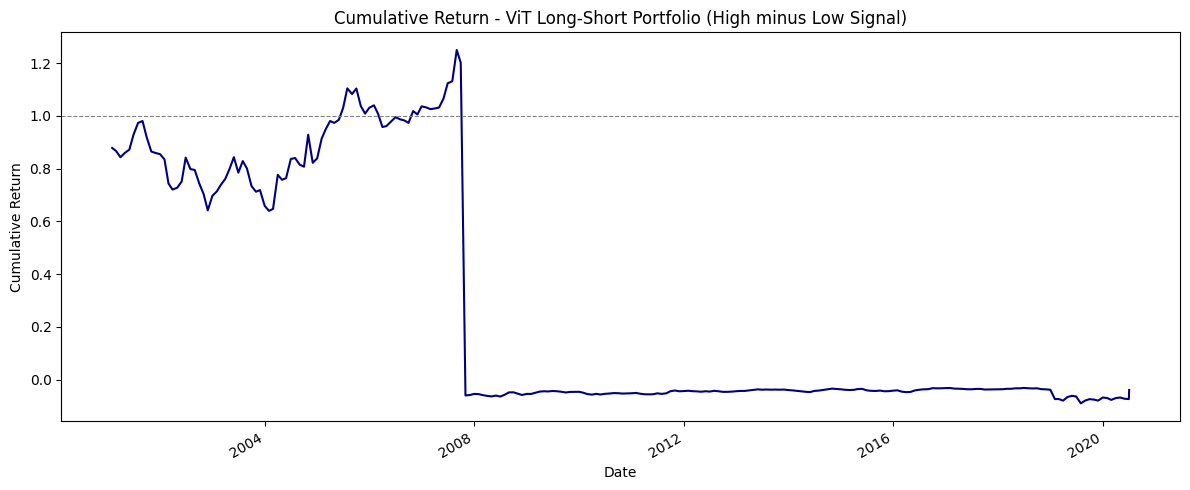

Chart saved


In [85]:
# Cumulative return chart
cum_ls = (1+ls).cumprod()
plt.figure(figsize=(12,5))
cum_ls.plot(color='navy', linewidth=1.5)
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8)
plt.title('Cumulative Return - ViT Long-Short Portfolio (High minus Low Signal)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.tight_layout()
plt.savefig('sorted_portfolio/ls_cumulative_return.png', dpi=150)
plt.show()
print('Chart saved')

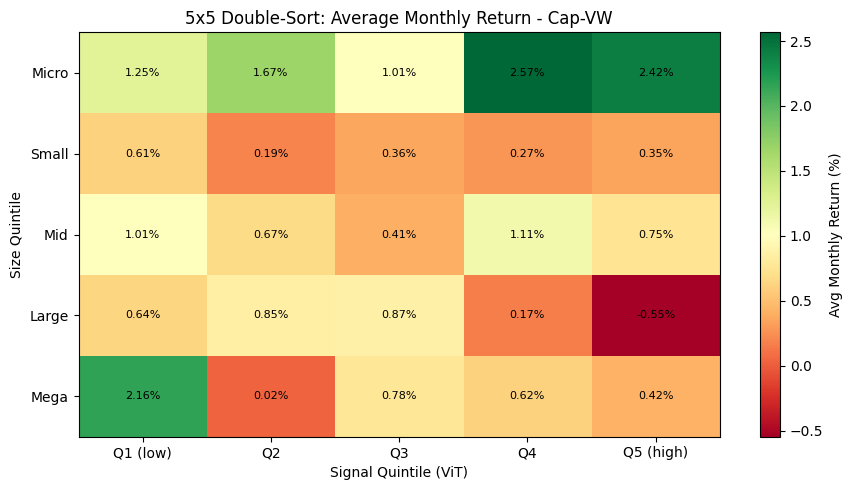

Heatmap saved


In [86]:
# 5x5 Heatmap
heatmap = df_5x5.groupby(['size_decile_5','signal_decile_5'])['Cap_VW_return'].mean().unstack()*100

fig, ax = plt.subplots(figsize=(9,5))
im = ax.imshow(heatmap.values, cmap='RdYlGn', aspect='auto')
plt.colorbar(im, ax=ax, label='Avg Monthly Return (%)')
ax.set_xticks(range(heatmap.shape[1]))
ax.set_xticklabels(['Q1 (low)','Q2','Q3','Q4','Q5 (high)'][:heatmap.shape[1]])
ax.set_yticks(range(heatmap.shape[0]))
ax.set_yticklabels(['Micro','Small','Mid','Large','Mega'][:heatmap.shape[0]])
ax.set_xlabel('Signal Quintile (ViT)')
ax.set_ylabel('Size Quintile')
ax.set_title('5x5 Double-Sort: Average Monthly Return - Cap-VW')
for i in range(heatmap.shape[0]):
    for j in range(heatmap.shape[1]):
        val = heatmap.values[i,j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}%', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('sorted_portfolio/heatmap_5x5.png', dpi=150)
plt.show()
print('Heatmap saved')

---
## Output Files

| File | Description |
|---|---|
| `sorted_portfolio/vit_5by5.csv` | Monthly returns for all 25 size x signal cells |
| `sorted_portfolio/vit_3by3.csv` | Monthly returns for all 9 size x signal cells |
| `sorted_portfolio/ls_cumulative_return.png` | Long-short cumulative chart |
| `sorted_portfolio/heatmap_5x5.png` | 5x5 return heat map |

